# Stage 2 — Healthy vs Symptomatic

二分類：`healthy` vs `symptomatic`（只用 non-covid 樣本）

特徵：516 維（512 HeAR + age + gender + respiratory + fever）

## Imports

In [1]:
import os
import numpy as np
import pandas as pd
import joblib
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import classification_report
from utils import plot_confusion_matrix

os.makedirs('checkpoints', exist_ok=True)

## Prepare Data

In [2]:
EMB_COLS  = [f'emb_{i}' for i in range(512)]
CLIN_COLS = ['age', 'gender_encoded', 'respiratory_condition', 'fever_muscle_pain']
FEATURES  = EMB_COLS + CLIN_COLS  # 516 維

df = pd.read_csv('data/prepared_train_hear.csv')
df = df[df['label'].isin(['healthy', 'symptomatic'])].copy()

df['label'] = df['label']

X = np.array(df[FEATURES], dtype=np.float32)
encoder = LabelEncoder()
y = encoder.fit_transform(df['label'])

print('classes:', encoder.classes_)
print('label 分佈:')
print(df['label'].value_counts())
print('X.shape:', X.shape)

indices = np.arange(len(y))
train_idx, test_idx = train_test_split(
    indices, test_size=0.2, random_state=42, stratify=y
)
X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]

scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)
print(f'X_train: {X_train.shape}, X_test: {X_test.shape}')

classes: ['healthy' 'symptomatic']
label 分佈:
label
symptomatic    553
healthy        543
Name: count, dtype: int64
X.shape: (1096, 516)
X_train: (876, 516), X_test: (220, 516)


## 5-Fold Cross Validation

K-FOLD CROSS VALIDATION RESULTS FOR 5 FOLDS
--------------------------------------------
|         | Train Accuracy | Test Accuracy |
--------------------------------------------
| Fold 0  |       73.17 % |       60.00 % |
| Fold 1  |       73.89 % |       68.49 % |
| Fold 2  |       71.49 % |       71.23 % |
| Fold 3  |       71.61 % |       68.04 % |
| Fold 4  |       71.84 % |       70.32 % |
--------------------------------------------
| Average |       72.40 % |       67.62 % |
| Std Dev |       0.96 % |       3.98 % |

              precision    recall  f1-score   support

     healthy       0.71      0.75      0.73       117
 symptomatic       0.69      0.65      0.67       102

    accuracy                           0.70       219
   macro avg       0.70      0.70      0.70       219
weighted avg       0.70      0.70      0.70       219



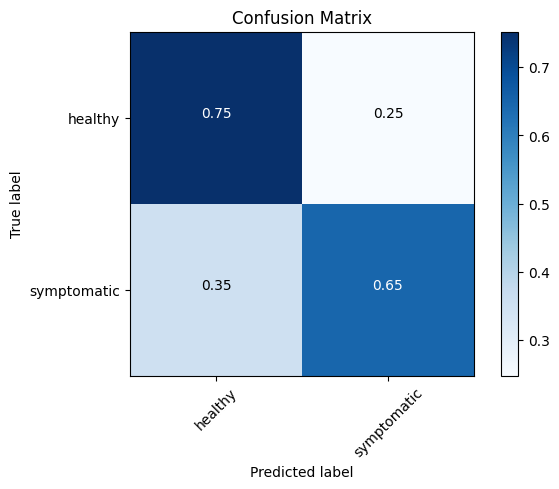

In [3]:
k_folds = 5
kfold   = KFold(n_splits=k_folds, shuffle=True, random_state=42)
results_train, results_test = [], []
last_preds, last_labels = None, None

print(f'K-FOLD CROSS VALIDATION RESULTS FOR {k_folds} FOLDS')
print('--------------------------------------------')
print('|         | Train Accuracy | Test Accuracy |')
print('--------------------------------------------')

for fold, (tr_ids, te_ids) in enumerate(kfold.split(np.arange(len(y)))):
    X_tr = StandardScaler().fit_transform(X[tr_ids])
    X_te = StandardScaler().fit(X[tr_ids]).transform(X[te_ids])
    y_tr, y_te = y[tr_ids], y[te_ids]

    clf_tmp = LogisticRegression(C=0.001, max_iter=1000, random_state=42, class_weight='balanced')
    clf_tmp.fit(X_tr, y_tr)

    tr_acc = clf_tmp.score(X_tr, y_tr)
    te_acc = clf_tmp.score(X_te, y_te)
    results_train.append(tr_acc)
    results_test.append(te_acc)
    last_preds  = clf_tmp.predict(X_te)
    last_labels = y_te
    print(f'| Fold {fold}  |       {tr_acc*100:.2f} % |       {te_acc*100:.2f} % |')

print('--------------------------------------------')
print(f'| Average |       {np.mean(results_train)*100:.2f} % |       {np.mean(results_test)*100:.2f} % |')
print(f'| Std Dev |       {np.std(results_train)*100:.2f} % |       {np.std(results_test)*100:.2f} % |')
print()
print(classification_report(last_labels, last_preds, target_names=encoder.classes_))
plot_confusion_matrix(last_labels, last_preds, encoder.classes_)

## 訓練最終模型 & 儲存

Train Accuracy: 72.37 %
Test Accuracy:  68.64 %
              precision    recall  f1-score   support

     healthy       0.66      0.76      0.71       109
 symptomatic       0.72      0.61      0.66       111

    accuracy                           0.69       220
   macro avg       0.69      0.69      0.68       220
weighted avg       0.69      0.69      0.68       220

Saved: checkpoints/stage2_healthy_vs_symptomatic.pkl
Test split saved: 220 筆


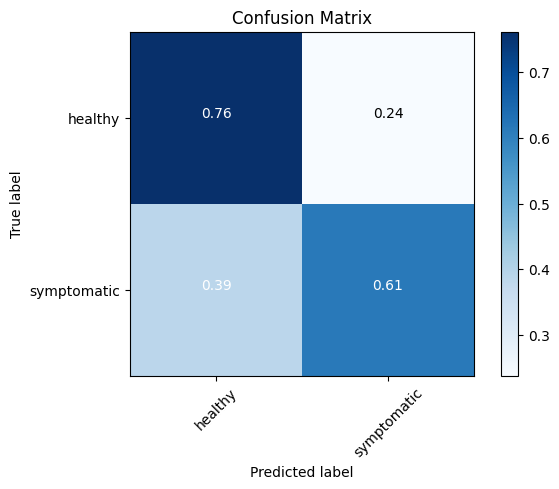

In [4]:
clf = LogisticRegression(C=0.001, max_iter=1000, random_state=42, class_weight='balanced')
clf.fit(X_train, y_train)

train_acc = clf.score(X_train, y_train)
test_acc  = clf.score(X_test,  y_test)
print(f'Train Accuracy: {train_acc*100:.2f} %')
print(f'Test Accuracy:  {test_acc*100:.2f} %')

predictions = clf.predict(X_test)
print(classification_report(y_test, predictions, target_names=encoder.classes_))
plot_confusion_matrix(y_test, predictions, encoder.classes_)

joblib.dump({
    'clf': clf, 'scaler': scaler,
    'encoder': encoder, 'features': FEATURES
}, 'checkpoints/stage2_healthy_vs_symptomatic.pkl')
print('Saved: checkpoints/stage2_healthy_vs_symptomatic.pkl')

# 儲存 test split 供 003 使用
df.iloc[test_idx].to_csv('data/prepared_test_split_hear.csv', index=False)
print(f'Test split saved: {len(test_idx)} 筆')